# Compare HESE events: Thijs (parquet) vs Zchen (cascade h5)

Compare overlapping events between:
- **Thijs**: `dataset_data_HESE_pass2_v3.parquet` (combined_with_bdt)
- **Zchen**: `withBDT_Fullcascade_Finallevel_2010-2022.h5`

Matching on `(run, event_id)` from `I3EventHeader`.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Configuration

In [88]:
# Set to a value in GeV to apply a reco_energy cut on the Thijs (HESE) sample,
# or None to use all events.
ENERGY_CUT_GEV = 60e3  # 60 TeV
# ENERGY_CUT_GEV = None

## 1. Load data

In [89]:
THIJS_PARQUET = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/combined_with_bdt/data_HESE_pass2_v3/"
    "mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/"
    "dataset_data_HESE_pass2_v3.parquet"
)

ZCHEN_H5 = (
    "/data/user/zchen/unblinding/signal_events/cascade_sample/"
    "withBDT_Fullcascade_Finallevel_2010-2022.h5"
)

df_t = pd.read_parquet(THIJS_PARQUET)
df_z = pd.read_hdf(ZCHEN_H5, key="hdf")

# Thijs: multi-index (run, event_id, subevent); flatten to flat columns
df_t = df_t.copy()
df_t["run"]      = df_t.index.get_level_values(0)
df_t["event_id"] = df_t.index.get_level_values(1)

# Zchen: event IDs from I3EventHeader columns
df_z = df_z.copy()
df_z["run"]      = df_z["I3EventHeader_Run"].astype(int)
df_z["event_id"] = df_z["I3EventHeader_Event"].astype(int)

print(f"Thijs events : {len(df_t)}")
print(f"Zchen events : {len(df_z)}")

Thijs events : 188
Zchen events : 17520


## 1b. Available variables in each dataset

In [90]:
# Thijs parquet — all columns
thijs_cols = list(df_t.columns)
print(f"=== Thijs parquet: {len(thijs_cols)} columns ===")
for i, c in enumerate(thijs_cols):
    print(f"  {i:3d}  {c}")

=== Thijs parquet: 76 columns ===
    0  event_id
    1  mjd
    2  reco_energy
    3  reco_energy_exists
    4  reco_energy_fit_status
    5  reco_dir_fit_status
    6  reco_dir
    7  reco_dir_exists
    8  reco_length
    9  reco_length_exists
   10  reco_length_fit_status
   11  FinalTopology
   12  FinalTopology_exists
   13  FinalEventClass
   14  FinalEventClass_exists
   15  TauMonoDiff_rlogl
   16  TauMonoDiff_rlogl_exists
   17  Taupede_Asymmetry
   18  Taupede_Asymmetry_exists
   19  Taupede_Distance
   20  Taupede_Distance_exists
   21  Taupede1_Particles_energy
   22  Taupede1_Particles_energy_exists
   23  Taupede2_Particles_energy
   24  Taupede2_Particles_energy_exists
   25  cscdSBU_MonopodFit4_noDC_zenith
   26  cscdSBU_MonopodFit4_noDC_zenith_exists
   27  MonopodFit_iMIGRAD_PPB0_Delay_ice
   28  MonopodFit_iMIGRAD_PPB0_Delay_ice_exists
   29  CVStatistics_q_max_doms
   30  CVStatistics_q_max_doms_exists
   31  cscdSBU_VertexRecoDist_CscdLLh
   32  cscdSBU_VertexReco

In [91]:
# Zchen h5 — exclude per-frame index copies (_Event/_Run/_SubEvent/_SubEventStream)
_IDX_SUFFIXES = ("_Event", "_Run", "_SubEvent", "_SubEventStream")
zchen_phys_cols = [c for c in df_z.columns if not any(c.endswith(s) for s in _IDX_SUFFIXES)]
print(f"\n=== Zchen h5: {len(df_z.columns)} total, {len(zchen_phys_cols)} after removing per-frame index copies ===")
for i, c in enumerate(zchen_phys_cols):
    print(f"  {i:3d}  {c}")


=== Zchen h5: 500 total, 348 after removing per-frame index copies ===
    0  CVMultiplicity_exists
    1  CVMultiplicity_n_hit_doms
    2  CVMultiplicity_n_hit_doms_one_pulse
    3  CVMultiplicity_n_hit_strings
    4  CVMultiplicity_n_pulses
    5  CVStatistics_cog_x
    6  CVStatistics_cog_y
    7  CVStatistics_cog_z
    8  CVStatistics_cog_z_sigma
    9  CVStatistics_exists
   10  CVStatistics_max_pulse_time
   11  CVStatistics_min_pulse_time
   12  CVStatistics_q_max_doms
   13  CVStatistics_q_tot_pulses
   14  CVStatistics_z_max
   15  CVStatistics_z_mean
   16  CVStatistics_z_min
   17  CVStatistics_z_sigma
   18  CVStatistics_z_travel
   19  Cascade1_vis_truth_tau_azimuth
   20  Cascade1_vis_truth_tau_energy
   21  Cascade1_vis_truth_tau_exists
   22  Cascade1_vis_truth_tau_fit_status
   23  Cascade1_vis_truth_tau_length
   24  Cascade1_vis_truth_tau_location
   25  Cascade1_vis_truth_tau_pdg_encoding
   26  Cascade1_vis_truth_tau_shape
   27  Cascade1_vis_truth_tau_speed
   28

## 2. Find overlapping events

In [92]:
t_keys = set(zip(df_t["run"], df_t["event_id"]))
z_keys = set(zip(df_z["run"], df_z["event_id"]))
overlap_keys_full = sorted(t_keys & z_keys)

# Build DataFrames restricted to overlapping events and index by (run, event_id)
full_key_set = set(overlap_keys_full)
df_t_ov = (
    df_t[df_t.apply(lambda r: (r["run"], r["event_id"]) in full_key_set, axis=1)]
    .copy()
    .set_index(["run", "event_id"])
)
df_z_ov = (
    df_z[df_z.apply(lambda r: (r["run"], r["event_id"]) in full_key_set, axis=1)]
    .copy()
    .set_index(["run", "event_id"])
)

# Apply optional energy cut on Thijs reco_energy
if ENERGY_CUT_GEV is not None:
    t_after_cut = df_t_ov[df_t_ov["reco_energy"] > ENERGY_CUT_GEV]
    overlap_keys = [k for k in overlap_keys_full if k in t_after_cut.index]
    cut_label = f"reco_energy > {ENERGY_CUT_GEV/1e3:.0f} TeV"
else:
    overlap_keys = overlap_keys_full
    cut_label = "no energy cut"

print(f"All overlap     : {len(overlap_keys_full)} events")
print(f"After cut ({cut_label}): {len(overlap_keys)} events")

All overlap     : 89 events
After cut (reco_energy > 60 TeV): 55 events


In [93]:
rows = []
for run, evt in overlap_keys:
    t_row = df_t_ov.loc[(run, evt)]
    if isinstance(t_row, pd.DataFrame):
        t_row = t_row.iloc[0]
    rows.append({
        "run":          run,
        "event_id":     evt,
        "mjd":          t_row["mjd"],
        "reco_energy":  t_row["reco_energy"],
    })

df_overlap = pd.DataFrame(rows).sort_values("run").reset_index(drop=True)

print(f"Overlap table ({len(df_overlap)} events, {cut_label}):")
pd.set_option("display.max_rows", None)
display(df_overlap.style.format({"mjd": "{:.6f}", "reco_energy": "{:.1f}"}))

Overlap table (55 events, reco_energy > 60 TeV):


,run,event_id,mjd,reco_energy
0,115994,29874216,55351.465966,102432.3
1,118381,19162840,55739.441123,89308.3
2,118545,63733662,55782.516191,964764.5
3,118607,40435683,55800.375548,184505.7
4,119214,8606380,55925.795862,65283.6
5,119316,36556705,55929.398628,1417014.1
6,119404,80750561,55941.975781,217154.6
7,119674,8449256,55979.255175,166096.4
8,120421,44633110,56115.728369,126749.4
9,121240,72944671,56265.133879,2111677.8


## 3. Comparison functions

Column-name mappings (found by value comparison on overlapping events):

| Thijs column | Zchen column | Notes |
|---|---|---|
| `reco_energy` | `MonopodFit_iMIGRAD_PPB0_energy` | MonopodFit energy, nearly identical |
| `reco_length` | `Taupede_ftp_length` | Taupede doubly-differential length |
| `bdt_scores1` | `bdt1_score` | Different BDT trainings |
| `bdt_scores2` | `bdt2_score` | Different BDT trainings |

In [94]:
import inspect

def compare_variables(overlap_keys, df_t_ov, df_z_ov, var_specs):
    """
    Build a per-event comparison table.

    Parameters
    ----------
    overlap_keys : list of (run, event_id) tuples
    df_t_ov      : Thijs DataFrame indexed by (run, event_id)
    df_z_ov      : Zchen DataFrame indexed by (run, event_id)
    var_specs    : list of (label, thijs_col, zchen_col)
                   Pass None for a column to fill with NaN.

    Returns
    -------
    pd.DataFrame with columns: run, event_id,
        {label}_thijs, {label}_zchen  for each entry in var_specs
    """
    rows = []
    for run, evt in overlap_keys:
        t_row = df_t_ov.loc[(run, evt)]
        z_row = df_z_ov.loc[(run, evt)]
        if isinstance(t_row, pd.DataFrame):
            t_row = t_row.iloc[0]
        if isinstance(z_row, pd.DataFrame):
            z_row = z_row.iloc[0]
        row = {"run": run, "event_id": evt}
        for label, t_col, z_col in var_specs:
            row[f"{label}_thijs"] = float(t_row[t_col]) if t_col is not None else np.nan
            row[f"{label}_zchen"] = float(z_row[z_col]) if z_col is not None else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values("run").reset_index(drop=True)


def plot_comparison_diffs(df_cmp, label, bins=20, transform=None, diff_label=None, title_suffix=""):
    """
    Plot a histogram of a difference quantity for a single variable.

    Parameters
    ----------
    df_cmp       : output of compare_variables()
    label        : variable name — must match a {label}_thijs / {label}_zchen column pair
    bins         : int (number of equal-width bins) or array of bin edges
    transform    : how to compute the plotted quantity from the two columns:
                     None                → thijs − zchen  (raw difference)
                     1-arg callable f    → f(thijs) − f(zchen)  (e.g. np.log10)
                     2-arg callable f    → f(thijs, zchen)       (e.g. relative difference)
    diff_label   : x-axis label override; auto-generated if None
    title_suffix : appended to the plot title
    """
    t_vals = df_cmp[f"{label}_thijs"]
    z_vals = df_cmp[f"{label}_zchen"]

    if transform is None:
        diff = (t_vals - z_vals).dropna()
        xlabel = diff_label or f"{label}:  thijs − zchen"
    else:
        n_args = len(inspect.signature(transform).parameters)
        if n_args == 1:
            diff = (t_vals.apply(transform) - z_vals.apply(transform)).dropna()
            fname = getattr(transform, "__name__", "f")
            xlabel = diff_label or f"{fname}({label}):  thijs − zchen"
        else:  # 2-arg: transform(thijs, zchen) → diff directly
            diff = transform(t_vals, z_vals).dropna()
            xlabel = diff_label or f"{label}:  custom transform"

    mean   = diff.mean()
    std    = diff.std()
    median = diff.median()
    q16    = diff.quantile(0.16)
    q84    = diff.quantile(0.84)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(diff, bins=bins, color="steelblue", alpha=0.7, edgecolor="white", linewidth=0.5)

    ax.axvline(mean,       color="C0", lw=2.0, linestyle="--", label=f"mean = {mean:.3g}")
    ax.axvline(mean + std, color="C0", lw=1.0, linestyle=":",  label=f"std  = {std:.3g}")
    ax.axvline(mean - std, color="C0", lw=1.0, linestyle=":")
    ax.axvline(median, color="C1", lw=2.0, linestyle="--", label=f"median = {median:.3g}")
    ax.axvline(q16,    color="C1", lw=1.0, linestyle=":",  label=f"q16 = {q16:.3g}")
    ax.axvline(q84,    color="C1", lw=1.0, linestyle=":",  label=f"q84 = {q84:.3g}")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("events")
    ax.set_title(f"{label}" + (f"  ({title_suffix})" if title_suffix else ""))
    ax.legend(fontsize=8, framealpha=0.85)
    fig.tight_layout()
    plt.show()

## 4. reco_energy and reco_length comparison

In [95]:
# Edit var_specs to add or swap variables
var_specs_reco = [
    # (display_label, thijs_column, zchen_column)
    ("reco_energy", "reco_energy", "MonopodFit_iMIGRAD_PPB0_energy"),
    ("reco_length", "reco_length", "Taupede_ftp_length"), #  Taupede_ftp_length Taupede_ftpParticles_length
]

df_reco_cmp = compare_variables(overlap_keys, df_t_ov, df_z_ov, var_specs_reco)

print(f"reco_energy [GeV] and reco_length [m] — {cut_label}")
display(df_reco_cmp.style.format({
    "reco_energy_thijs": "{:.1f}",
    "reco_energy_zchen": "{:.1f}",
    "reco_length_thijs": "{:.2f}",
    "reco_length_zchen": "{:.2f}",
}))

reco_energy [GeV] and reco_length [m] — reco_energy > 60 TeV


,run,event_id,reco_energy_thijs,reco_energy_zchen,reco_length_thijs,reco_length_zchen
0,115994,29874216,102432.3,101451.8,77.01,77.29
1,118381,19162840,89308.3,90924.9,10.87,8.37
2,118545,63733662,964764.5,962188.2,5.00,4.43
3,118607,40435683,184505.7,185248.2,6.59,8.93
4,119214,8606380,65283.6,65493.9,102.70,102.57
5,119316,36556705,1417014.1,1338880.3,8.59,9.51
6,119404,80750561,217154.6,216606.7,6.84,4.55
7,119674,8449256,166096.4,168115.5,39.44,47.75
8,120421,44633110,126749.4,127397.4,5.69,3.94
9,121240,72944671,2111677.8,nan,8.37,8.62


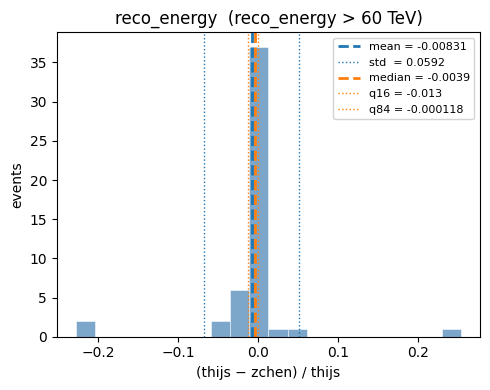

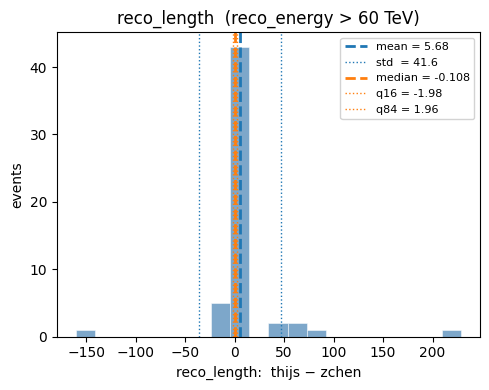

In [96]:
plot_comparison_diffs(df_reco_cmp, "reco_energy", bins=20,
                      transform=lambda t, z: (t - z) / t,
                      diff_label="(thijs − zchen) / thijs",
                      title_suffix=cut_label)
plot_comparison_diffs(df_reco_cmp, "reco_length", bins=20, title_suffix=cut_label)

## 5. BDT score comparison

Note: the two datasets use **different BDT trainings**, so scores are not expected to match.

In [97]:
var_specs_bdt = [
    # (display_label, thijs_column, zchen_column)
    ("bdt_score1", "bdt_scores1", "bdt1_score"),
    ("bdt_score2", "bdt_scores2", "bdt2_score"),
]

df_bdt_cmp = compare_variables(overlap_keys, df_t_ov, df_z_ov, var_specs_bdt)

print(f"BDT score comparison — {cut_label}")
display(df_bdt_cmp.style.format({
    "bdt_score1_thijs": "{:.4f}",
    "bdt_score1_zchen": "{:.4f}",
    "bdt_score2_thijs": "{:.4f}",
    "bdt_score2_zchen": "{:.4f}",
}))

BDT score comparison — reco_energy > 60 TeV


,run,event_id,bdt_score1_thijs,bdt_score1_zchen,bdt_score2_thijs,bdt_score2_zchen
0,115994,29874216,0.8307,0.6667,0.0649,0.0154
1,118381,19162840,0.0135,0.0155,0.5859,0.4693
2,118545,63733662,0.3204,0.6551,0.8522,0.9504
3,118607,40435683,0.0011,0.0019,0.6667,0.6364
4,119214,8606380,0.0243,0.0119,0.0310,0.0139
5,119316,36556705,0.9720,0.9854,0.9833,0.9934
6,119404,80750561,0.9046,0.9405,0.9489,0.9125
7,119674,8449256,0.0019,0.0054,0.1380,0.2036
8,120421,44633110,0.1405,0.9899,0.6484,0.9530
9,121240,72944671,0.1557,0.4073,0.9584,0.8707


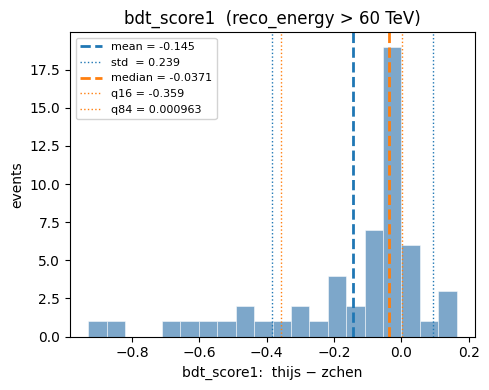

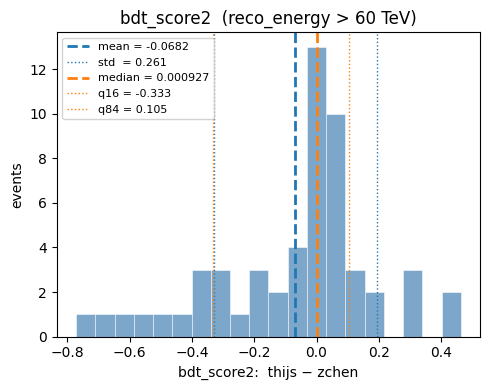

In [98]:
plot_comparison_diffs(df_bdt_cmp, "bdt_score1", bins=20, title_suffix=cut_label)
plot_comparison_diffs(df_bdt_cmp, "bdt_score2", bins=20, title_suffix=cut_label)

## 6. Track/double-cascade selection on overlapping events

Starting from the **89 overlapping events** (no energy cut), apply cuts independently to each dataset:
`reco_length > 10 m`, `bdt1 > 0.333333`, `bdt2 > 0.366667`.

Column mapping:

| | `reco_length` | `bdt1` | `bdt2` |
|---|---|---|---|
| **Thijs** | `reco_length` | `bdt_scores1` | `bdt_scores2` |
| **Zchen** | `Taupede_ftp_length` | `bdt1_score` | `bdt2_score` |

In [99]:
LENGTH_CUT = 10.0
BDT1_CUT   = 0.333333
BDT2_CUT   = 0.366667

In [100]:
# --- Thijs: apply cuts within the overlapping events ---
mask_t = (
    (df_t_ov["reco_length"]  > LENGTH_CUT) &
    (df_t_ov["bdt_scores1"] > BDT1_CUT)   &
    (df_t_ov["bdt_scores2"] > BDT2_CUT)
)
df_t_sel = df_t_ov[mask_t].copy().reset_index()

display_cols_t = ["run", "event_id", "mjd", "reco_energy", "reco_length", "bdt_scores1", "bdt_scores2"]
df_t_sel_disp  = df_t_sel[display_cols_t].sort_values("run").reset_index(drop=True)

print(f"Thijs: {len(df_t_sel_disp)} / {len(overlap_keys_full)} overlapping events pass (length>{LENGTH_CUT}, bdt1>{BDT1_CUT}, bdt2>{BDT2_CUT})")
display(df_t_sel_disp.style.format({
    "mjd":          "{:.6f}",
    "reco_energy":  "{:.1f}",
    "reco_length":  "{:.2f}",
    "bdt_scores1":  "{:.4f}",
    "bdt_scores2":  "{:.4f}",
}))

Thijs: 2 / 89 overlapping events pass (length>10.0, bdt1>0.333333, bdt2>0.366667)


,run,event_id,mjd,reco_energy,reco_length,bdt_scores1,bdt_scores2
0,120638,2924273,56176.391426,36979.4,15.54,0.8225,0.6019
1,126283,47286594,57134.398131,98091.7,17.93,0.9971,0.9912


In [101]:
# --- Zchen: apply cuts within the overlapping events ---
mask_z = (
    (df_z_ov["Taupede_ftp_length"] > LENGTH_CUT) &
    (df_z_ov["bdt1_score"]         > BDT1_CUT)   &
    (df_z_ov["bdt2_score"]         > BDT2_CUT)
)
df_z_sel = df_z_ov[mask_z].copy().reset_index()
df_z_sel["mjd"] = df_z_sel["I3EventHeader_time_start_mjd"]

display_cols_z = ["run", "event_id", "mjd",
                  "MonopodFit_iMIGRAD_PPB0_energy", "Taupede_ftp_length",
                  "bdt1_score", "bdt2_score"]
df_z_sel_disp = df_z_sel[display_cols_z].sort_values("run").reset_index(drop=True)

print(f"Zchen: {len(df_z_sel_disp)} / {len(overlap_keys_full)} overlapping events pass (length>{LENGTH_CUT}, bdt1>{BDT1_CUT}, bdt2>{BDT2_CUT})")
display(df_z_sel_disp.rename(columns={
    "MonopodFit_iMIGRAD_PPB0_energy": "reco_energy",
    "Taupede_ftp_length":             "reco_length",
}).style.format({
    "mjd":         "{:.6f}",
    "reco_energy": "{:.1f}",
    "reco_length": "{:.2f}",
    "bdt1_score":  "{:.4f}",
    "bdt2_score":  "{:.4f}",
}))

Zchen: 3 / 89 overlapping events pass (length>10.0, bdt1>0.333333, bdt2>0.366667)


,run,event_id,mjd,reco_energy,reco_length,bdt1_score,bdt2_score
0,120638,2924273,56176.391414,42258.2,16.04,0.9117,0.9573
1,126283,47286594,57134.398120,100093.7,18.24,0.9945,0.9904
2,126320,6425207,57144.296066,nan,12.96,0.6151,0.9108


In [102]:
# Events passing in both / only one dataset
t_sel_keys = set(zip(df_t_sel["run"], df_t_sel["event_id"]))
z_sel_keys = set(zip(df_z_sel["run"], df_z_sel["event_id"]))
both   = sorted(t_sel_keys & z_sel_keys)
only_t = sorted(t_sel_keys - z_sel_keys)
only_z = sorted(z_sel_keys - t_sel_keys)

print(f"Pass in both       : {len(both)} event(s)  → {both}")
print(f"Thijs only         : {len(only_t)} event(s) → {only_t}")
print(f"Zchen only         : {len(only_z)} event(s) → {only_z}")

Pass in both       : 2 event(s)  → [(120638, 2924273), (126283, 47286594)]
Thijs only         : 0 event(s) → []
Zchen only         : 1 event(s) → [(126320, 6425207)]


### 6b. Side-by-side comparison for all events passing in either dataset

In [103]:
rows = []
for run, evt in sorted(t_sel_keys | z_sel_keys):
    # Always look up from both datasets (all union events are in the 89-event overlap)
    t_row = df_t_ov.loc[(run, evt)]
    z_row = df_z_ov.loc[(run, evt)]
    if isinstance(t_row, pd.DataFrame): t_row = t_row.iloc[0]
    if isinstance(z_row, pd.DataFrame): z_row = z_row.iloc[0]
    rows.append({
        ("",             "run"):       run,
        ("",             "event_id"):  evt,
        ("",             "in"):        ("both"  if (run, evt) in both
                                        else "thijs" if (run, evt) in t_sel_keys
                                        else "zchen"),
        ("reco_length",  "thijs"):     float(t_row["reco_length"]),
        ("reco_length",  "zchen"):     float(z_row["Taupede_ftp_length"]),
        ("reco_energy",  "thijs"):     float(t_row["reco_energy"]),
        ("reco_energy",  "zchen"):     float(z_row["MonopodFit_iMIGRAD_PPB0_energy"]),
        ("bdt_score1",   "thijs"):     float(t_row["bdt_scores1"]),
        ("bdt_score1",   "zchen"):     float(z_row["bdt1_score"]),
        ("bdt_score2",   "thijs"):     float(t_row["bdt_scores2"]),
        ("bdt_score2",   "zchen"):     float(z_row["bdt2_score"]),
    })

df_union = pd.DataFrame(rows)
df_union.columns = pd.MultiIndex.from_tuples(df_union.columns)

print(f"All events passing in Thijs or Zchen ({len(df_union)} events):")
display(df_union.style.format({
    ("reco_length", "thijs"):  "{:.2f}",
    ("reco_length", "zchen"):  "{:.2f}",
    ("reco_energy",  "thijs"): "{:.1f}",
    ("reco_energy",  "zchen"): "{:.1f}",
    ("bdt_score1",   "thijs"): "{:.4f}",
    ("bdt_score1",   "zchen"): "{:.4f}",
    ("bdt_score2",   "thijs"): "{:.4f}",
    ("bdt_score2",   "zchen"): "{:.4f}",
}))

All events passing in Thijs or Zchen (3 events):


## 7. Full row extraction: run 126320, event 6425207

This event passes the Zchen selection but not the Thijs selection.
It is present in the overlap (89 events), so both datasets have a row for it.

In [104]:
INSPECT_RUN = 126320
INSPECT_EVT = 6425207

# --- Thijs ---
t_full = df_t_ov.loc[(INSPECT_RUN, INSPECT_EVT)]
if isinstance(t_full, pd.DataFrame):
    t_full = t_full.iloc[0]
df_t_full = t_full.to_frame(name=f"run {INSPECT_RUN} / evt {INSPECT_EVT}")

print(f"Thijs parquet — run {INSPECT_RUN}, event {INSPECT_EVT} ({len(df_t_full)} variables):")
display(df_t_full)

# --- Zchen ---
z_full = df_z_ov.loc[(INSPECT_RUN, INSPECT_EVT)]
if isinstance(z_full, pd.DataFrame):
    z_full = z_full.iloc[0]
# run/event_id are the index in df_z_ov so they're not in the Series; intersect to be safe
avail_z = [c for c in zchen_phys_cols if c in z_full.index]
df_z_full = z_full[avail_z].to_frame(name=f"run {INSPECT_RUN} / evt {INSPECT_EVT}")

print(f"\nZchen h5 — run {INSPECT_RUN}, event {INSPECT_EVT} ({len(df_z_full)} variables, index copies excluded):")
display(df_z_full)

Thijs parquet — run 126320, event 6425207 (74 variables):


,run 126320 / evt 6425207
mjd,57144.296078
reco_energy,34362.818703
reco_energy_exists,1
reco_energy_fit_status,0
reco_dir_fit_status,0
reco_dir,2.100017
reco_dir_exists,1
reco_length,29.482838
reco_length_exists,1
reco_length_fit_status,1



Zchen h5 — run 126320, event 6425207 (346 variables, index copies excluded):


,run 126320 / evt 6425207
CVMultiplicity_exists,1.0
CVMultiplicity_n_hit_doms,125.0
CVMultiplicity_n_hit_doms_one_pulse,48.0
CVMultiplicity_n_hit_strings,17.0
CVMultiplicity_n_pulses,1703.0
CVStatistics_cog_x,-190.404548
CVStatistics_cog_y,257.417883
CVStatistics_cog_z,278.121448
CVStatistics_cog_z_sigma,24.831752
CVStatistics_exists,1.0
